# 01 — Generative vs Discriminative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Compare generative models (learn p(x, y) — can *create* data) and discriminative models (learn p(y|x) — can only *label* data)
- See both paradigms trained on the same dataset, side by side
- Preview a GAN — the modern deep generative model you will build in example 05

## 🔗 Prerequisites

- ✅ Python, NumPy, matplotlib
- ✅ scikit-learn basics (Course 04)
- ✅ PyTorch training loops (Course 08) — used in the GAN preview

---

## Introduction

A **discriminative** model learns the boundary between classes: it models p(y|x) and can answer "which class is this?" — nothing more.
A **generative** model learns what the data itself looks like: it models p(x|y) (or p(x)) and can therefore **sample brand-new data points**, as well as classify via Bayes' rule.

Below we train one of each on the same 2-D dataset and visualize exactly what each one learns.


## Part 1 — The Two Paradigms on the Same Dataset

We use a simple 2-class, 2-D dataset so everything is visible:

- **Generative model**: Gaussian Naive Bayes — fits a Gaussian distribution *per class* (this IS a model of p(x|y)), classifies with Bayes' rule, and can **sample new points** from the fitted Gaussians.
- **Discriminative model**: Logistic Regression — fits only the decision boundary p(y|x); it has no idea what the data looks like away from the boundary and **cannot generate anything**.


Test accuracy — generative (GaussianNB):        97.2%
Test accuracy — discriminative (LogisticReg.):  96.1%


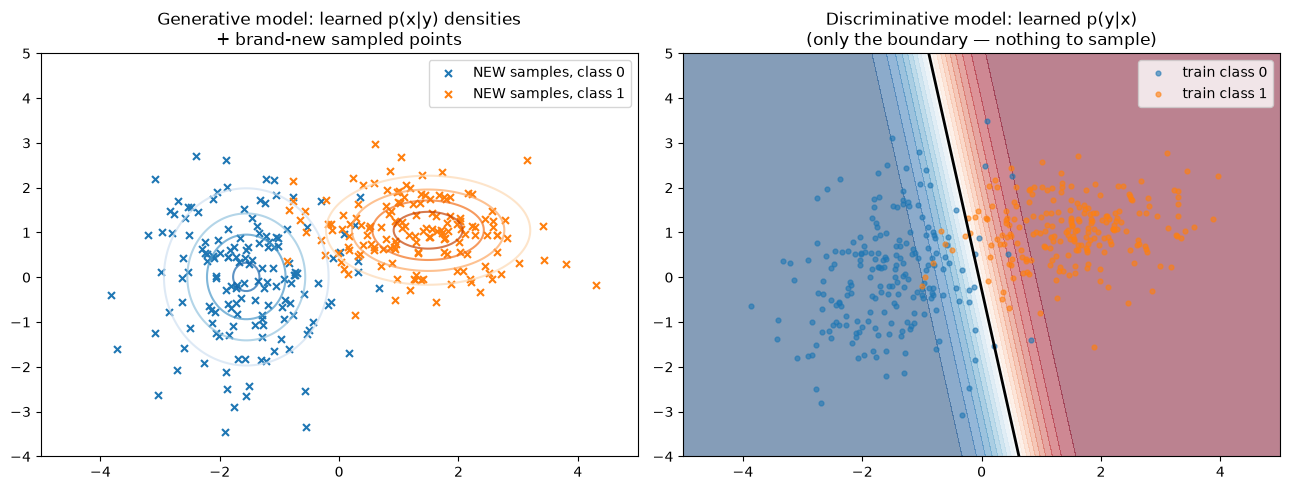


Key point: both models classify well, but only the generative model
also learned the data distribution — so only it can generate new points.


In [1]:
# WHAT/WHY: train a generative model (Gaussian Naive Bayes) and a discriminative
# model (Logistic Regression) on the SAME 2-D dataset, then visualize what each
# one learned — the generative model can sample new data; the discriminative
# model only draws a boundary. This is the core comparison of this lesson.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)

# ── Build a 2-class, 2-D dataset (two Gaussian blobs) ─────────────────────
n_per_class = 300
X0 = rng.normal(loc=[-1.5, 0.0], scale=[0.8, 1.2], size=(n_per_class, 2))  # class 0
X1 = rng.normal(loc=[+1.5, 1.0], scale=[1.0, 0.7], size=(n_per_class, 2))  # class 1
X = np.vstack([X0, X1])
y = np.array([0] * n_per_class + [1] * n_per_class)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

# ── Fit both models on the same training split ────────────────────────────
gen_model  = GaussianNB().fit(X_tr, y_tr)           # generative: one Gaussian per class
disc_model = LogisticRegression().fit(X_tr, y_tr)   # discriminative: boundary only

# ── Both can classify — print held-out accuracy for each ──────────────────
acc_gen  = gen_model.score(X_te, y_te)
acc_disc = disc_model.score(X_te, y_te)
print(f"Test accuracy — generative (GaussianNB):        {acc_gen*100:.1f}%")
print(f"Test accuracy — discriminative (LogisticReg.):  {acc_disc*100:.1f}%")

# ── Only the GENERATIVE model can create new data ─────────────────────────
# Sample from the per-class Gaussians the model fitted (mean theta_, var var_).
def sample_from_gnb(model, cls, n):
    mean = model.theta_[cls]          # fitted class mean
    std  = np.sqrt(model.var_[cls])   # fitted class std (diagonal covariance)
    return rng.normal(mean, std, size=(n, 2))

new0 = sample_from_gnb(gen_model, 0, 150)  # brand-new synthetic class-0 points
new1 = sample_from_gnb(gen_model, 1, 150)  # brand-new synthetic class-1 points

# ── Visualization: generative view (left) vs discriminative view (right) ──
xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-4, 5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: what the generative model learned — class densities + NEW samples
for cls, color in [(0, "Blues"), (1, "Oranges")]:
    dens = multivariate_normal(gen_model.theta_[cls], np.diag(gen_model.var_[cls])).pdf(grid)
    axes[0].contour(xx, yy, dens.reshape(xx.shape), levels=4, cmap=color, alpha=0.7)
axes[0].scatter(new0[:, 0], new0[:, 1], c="tab:blue",   marker="x", s=25, label="NEW samples, class 0")
axes[0].scatter(new1[:, 0], new1[:, 1], c="tab:orange", marker="x", s=25, label="NEW samples, class 1")
axes[0].set_title("Generative model: learned p(x|y) densities\n+ brand-new sampled points")
axes[0].legend()

# Right: what the discriminative model learned — only a decision boundary
proba = disc_model.predict_proba(grid)[:, 1].reshape(xx.shape)
axes[1].contourf(xx, yy, proba, levels=20, cmap="RdBu_r", alpha=0.5)
axes[1].contour(xx, yy, proba, levels=[0.5], colors="black", linewidths=2)
axes[1].scatter(X_tr[y_tr == 0, 0], X_tr[y_tr == 0, 1], c="tab:blue",   s=12, alpha=0.6, label="train class 0")
axes[1].scatter(X_tr[y_tr == 1, 0], X_tr[y_tr == 1, 1], c="tab:orange", s=12, alpha=0.6, label="train class 1")
axes[1].set_title("Discriminative model: learned p(y|x)\n(only the boundary — nothing to sample)")
axes[1].legend()
plt.tight_layout(); plt.show()

print("\nKey point: both models classify well, but only the generative model")
print("also learned the data distribution — so only it can generate new points.")


## Part 2 — Preview: a GAN, the Modern Deep Generative Model

The Gaussian model above works because our toy data really is Gaussian. Real data (images, audio, text) is far too complex for a hand-picked distribution — so modern generative models **learn** the distribution with neural networks. The most famous example is the **GAN (Generative Adversarial Network)**.

**How the training below works** (you will build this yourself, step by step, in example 05 — here it is a preview):

- The **Generator (G)** is a neural network that maps random noise `z` → a 28×28 image. It plays the *generative* role.
- The **Discriminator (D)** is a neural network that maps an image → "probability it is real". It is literally a *discriminative* classifier — this lesson's two paradigms working together!
- Training alternates every batch:
  1. **D step**: show D real images labeled 1 and G's fakes labeled 0; update D to tell them apart. (`G(z).detach()` stops this step from also updating G.)
  2. **G step**: update G so that D scores its fakes as 1 — i.e., G improves by learning to *fool* D.
- As D gets stricter, G gets better — until G's samples start to look like real digits.

**Industry context:** GANs are used to generate synthetic training data (e.g., for autonomous-driving datasets), candidate molecular structures in drug discovery, and design mockups in fashion.

The network below is a small **fully-connected GAN** (a real DCGAN uses convolutional layers — see the references). Three quick epochs on a 12,800-image MNIST subset are enough to watch digits emerge from noise.


Epoch 1/3 — D loss: 1.093  G loss: 1.010


Epoch 2/3 — D loss: 0.822  G loss: 1.025


Epoch 3/3 — D loss: 0.954  G loss: 0.759


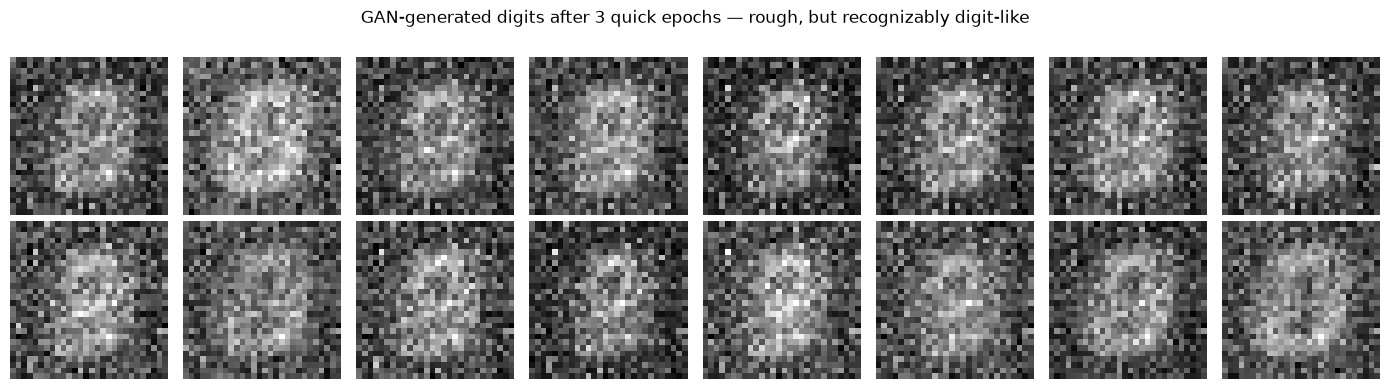

In [2]:
# WHAT/WHY: preview of GAN training — a Generator learns to turn random noise
# into digit images by trying to fool a Discriminator. Full walkthrough in
# example 05; here, watch the adversarial loop run and look at the samples.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

# ── Data: MNIST scaled to [-1, 1] to match the Generator's Tanh output ────
transform = T.Compose([T.ToTensor(), T.Normalize([0.5], [0.5])])
dataset   = torchvision.datasets.MNIST('./data/mnist', train=True, download=True, transform=transform)
# Classroom-sized subset: 12,800 images keep this preview fast on CPU
subset    = torch.utils.data.Subset(dataset, range(12_800))
loader    = torch.utils.data.DataLoader(subset, batch_size=BATCH, shuffle=True)

# ── Generator: noise vector (64) → flattened 28×28 image ──────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
# ── Discriminator: flattened image → probability it is real ───────────────
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce   = nn.BCELoss()

d_losses, g_losses = [], []
EPOCHS = 3  # enough to see digits emerge from noise; raise for sharper samples
for epoch in range(EPOCHS):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        # ── D step: real images → label 1, G's fakes → label 0 ────────────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()  # detach: this step must not update G
        loss_D = bce(D(real_flat), torch.ones(bs, 1)) + bce(D(fake), torch.zeros(bs, 1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # ── G step: update G so D scores its fakes as "real" (label 1) ────
        z      = torch.randn(bs, LATENT_DIM)
        fake   = G(z)
        loss_G = bce(D(fake), torch.ones(bs, 1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    d_losses.append(loss_D.item()); g_losses.append(loss_G.item())
    print(f"Epoch {epoch+1}/{EPOCHS} — D loss: {d_losses[-1]:.3f}  G loss: {g_losses[-1]:.3f}")

# ── Sample 16 images from the trained Generator and display them ──────────
G.eval()
with torch.no_grad():
    samples = G(torch.randn(16, LATENT_DIM)).view(16, 28, 28).numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray'); ax.axis('off')
plt.suptitle("GAN-generated digits after 3 quick epochs — rough, but recognizably digit-like")
plt.tight_layout(); plt.show()


---

## ✅ Summary

**What you learned:**
- **Discriminative models** learn p(y|x): great at labeling, unable to create. Our logistic regression classified the toy data well but has nothing to sample from.
- **Generative models** learn the data distribution: our Gaussian model classified *and* produced brand-new points from its fitted p(x|y).
- **GAN preview**: modern generative models learn complex distributions with neural networks — a Generator (generative role) trained adversarially against a Discriminator (discriminative role). Example 05 builds this in full detail.

**Next steps:**
- Example 02 compares the main deep generative *families* (GANs, VAEs, flows)
- Example 03 goes deeper into probabilistic generative models and log-likelihood


## 📚 References & Further Reading

**Foundational Papers:**
- Ng & Jordan (2001) — [On Discriminative vs. Generative Classifiers](https://papers.nips.cc/paper/2020-on-discriminative-vs-generative-classifiers) *(the classic comparison)*
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(invented GANs)*
- Radford et al. (2015) — [DCGAN](https://arxiv.org/abs/1511.06434) *(the convolutional GAN our preview simplifies)*

**State-of-the-Art:**
- Modern image generators (DALL-E, Midjourney, Stable Diffusion) combine these generative ideas with diffusion — taught in Unit 3
